# **Tarea 2 - Procesamiendo Digital de Imágenes**

Integrantes:
* Andrea Correa Arango - 1001391488
* Julian Isaza Marin - 1001478400
* Simón Sánchez Sepúlveda - 1193042029


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    print(f" cargada desde la carpeta del proyecto.")
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title('Imagen de Prueba Cargada')
    plt.axis('off')
    plt.show()
else:
    print(f"No se encontró el archivo '{nombre_imagen}' en la carpeta.")


# **Parte 1: Filtros**

1. (30%) Investigar/Consultar y definir los siguientes filtros (la investigación debe contener la fórmula matemática, un ejemplo y su explicación):

    * Filtro de media
    * Filtro de mediana
    * Filtro logarítmico
    * Filtro de cuadro normalizado
    * Filtro gaussiano
    * Filtro Laplace
    * Filtro Sobel
    * Filtro Canny

2. De los filtros definidos en el numeral describir ventajas y desventajas

3. De los filtros definidos en el numeral 1 programar un ejemplo usando opencv ó Matlab por cada literal  


##**Filtro de Media**

###**Definición**
El filtro de media es un filtro espacial lineal de paso bajo cuya función principal es el suavizado de la imagen. Opera mediante la convolución de una máscara (o kernel) sobre la imagen original. En cada posición, el valor del píxel central es reemplazado por la media aritmética de los niveles de intensidad de todos los píxeles contenidos dentro de la vecindad definida por la máscara. Al hacer esto, el filtro atenúa las altas frecuencias espaciales, las cuales corresponden típicamente a ruido aleatorio o transiciones bruscas de intensidad.

Matemáticamente, dada una imagen $f(x,y)$ y una máscara de tamaño $M \times N$, el píxel resultante $g(x,y)$ es:

$$g(x,y) = \frac{1}{M \cdot N} \sum_{s=-a}^{a} \sum_{t=-b}^{b} f(x+s, y+t)$$

(Donde $a = (M-1)/2$ y $b = (N-1)/2$)

###**Ventajas**
* Reducción efectiva del ruido Gaussiano o ruido continuo aleatorio.
* Simplicidad algorítmica y bajo costo computacional (especialmente si se implementa como filtros separables 1D).
###**Desventajas**
* Efecto secundario de difuminación (blurring) que degrada la nitidez de los bordes y detalles estructurales de alta frecuencia.
* Alta susceptibilidad a valores atípicos (outliers).
* Un solo píxel con un valor extremo alterará significativamente el promedio de toda su vecindad.

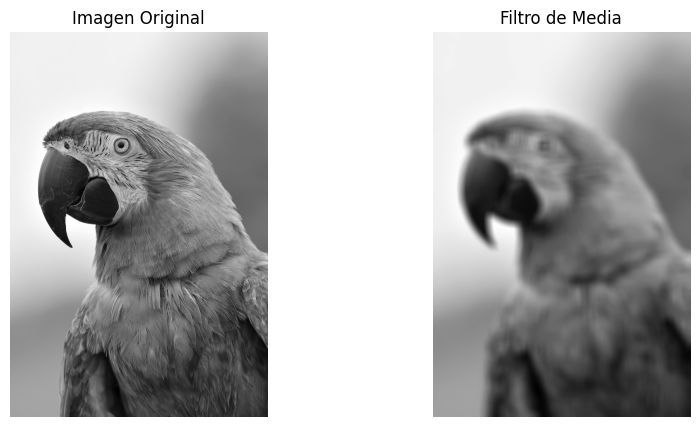

In [ ]:
# Aplicación del filtro de media con un kernel de 151x151
img_media = cv2.blur(img, (151, 151))

# Visualización comparativa
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_media, cmap='gray')
plt.title('Filtro de Media')
plt.axis('off')

plt.show()

##**Filtro de Mediana**

###**Definición**
El filtro de mediana es un filtro espacial no lineal basado en estadísticas de orden. A diferencia de los filtros lineales que aplican operaciones aritméticas, este filtro analiza la vecindad de cada píxel, ordena los valores de intensidad de forma ascendente (o descendente) y sustituye el píxel central por el valor correspondiente a la mediana estadística de dicho conjunto.

Matemáticamente:
$$g(x,y) = \text{mediana} \{ f(x+s, y+t) \mid (s,t) \in S_{xy} \}$$

(Donde $S_{xy}$ representa el conjunto de coordenadas de la vecindad centrada en $x,y$)

###**Ventajas**
* Elimina de manera excepcionalmente eficiente el ruido impulsivo (conocido como ruido de "sal y pimienta").
* Conserva los bordes afilados de los objetos mucho mejor que los filtros lineales (como la media o el gaussiano).
* Es robusto frente a valores atípicos extremos, ya que estos quedan en los bordes de la lista al ordenar y son descartados.
###**Desventajas**
* Es computacionalmente más costoso que los filtros lineales porque requiere ejecutar algoritmos de ordenamiento para cada píxel.Si se usan ventanas (kernels) muy grandes, puede llegar a borrar detalles estructurales delgados, como líneas finas o esquinas agudas.

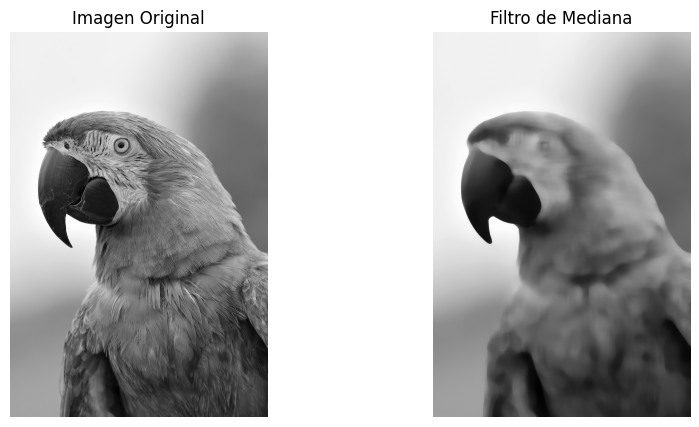

In [ ]:
# Aplicación del filtro de mediana con un tamaño de vecindad de 151
img_mediana = cv2.medianBlur(img, 151)

# Visualización comparativa
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_mediana, cmap='gray')
plt.title('Filtro de Mediana')
plt.axis('off')

plt.show()

##**Filtro Logarítmico**

###**Definición**
Corresponde a una transformación de intensidad puntual (opera sobre píxeles individuales, sin depender de una vecindad) que mapea los valores de entrada utilizando una función logarítmica. Su propósito fundamental es la compresión del rango dinámico: expande los rangos estrechos de niveles de intensidad bajos (sombras oscuras) haciéndolos más visibles, mientras que comprime los rangos amplios de niveles de intensidad altos.

Matemáticamente:
$$g(x,y) = c \cdot \log(1 + f(x,y))$$

(Donde $c$ es una constante de escala para asegurar que los valores no superen el límite de la imagen, y se suma $1$ para evitar calcular el logaritmo de 0).

###**Ventajas**
* Excelente para revelar detalles ocultos en las sombras o en imágenes subexpuestas.
* Muy útil para comprimir imágenes con un rango dinámico excesivamente amplio, permitiendo visualizar datos complejos (como el espectro de magnitud de una Transformada de Fourier).
###**Desventajas**
* Reduce severamente el contraste en las zonas más claras o brillantes de la imagen (las "aplasta" o las lava).
* No es un filtro diseñado para eliminar ruido, por lo que el ruido presente en las zonas oscuras también se amplificará y se hará más visible.

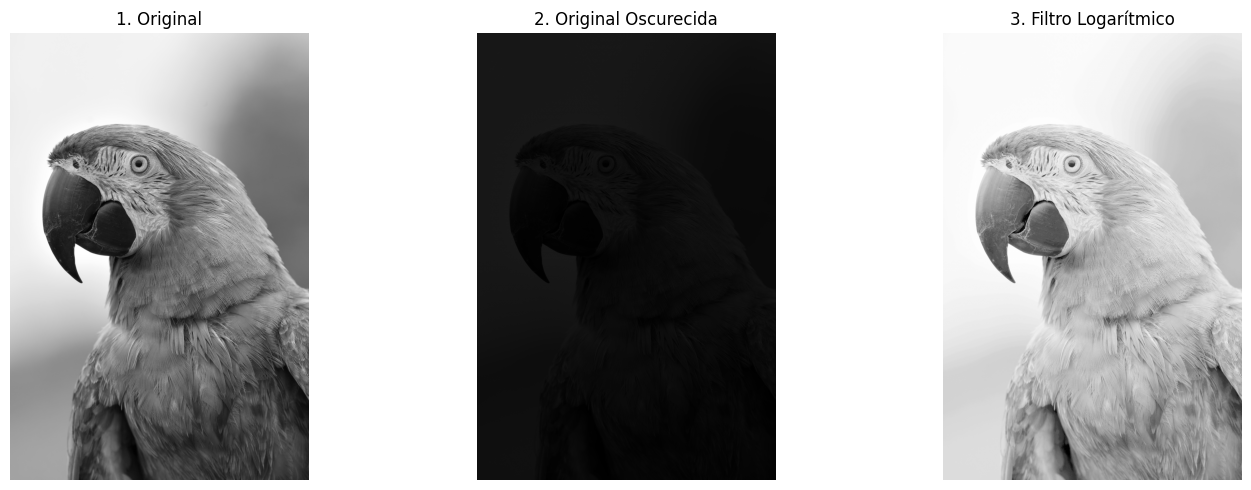

In [ ]:
# Multiplicamos la intensidad de todos los píxeles por 0.1 para bajar su brillo al 10%
img_oscura = np.clip(img * 0.1, 0, 255).astype(np.uint8)

img_float = np.float32(img_oscura)

# Calculamos la constante 'c' para escalar el resultado
c = 255.0 / np.log(1.0 + np.max(img_float))

img_log_float = c * (np.log(1.0 + img_float))

img_log = np.uint8(img_log_float)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('1. Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_oscura, cmap='gray', vmin=0, vmax=255)
plt.title('2. Original Oscurecida')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_log, cmap='gray', vmin=0, vmax=255)
plt.title('3. Filtro Logarítmico')
plt.axis('off')

plt.tight_layout()
plt.show()

##**Filtro de Cuadro Normalizado**

###**Definición**
Es un tipo específico y estandarizado de filtro de media (filtro lineal de paso bajo). Consiste en una convolución donde la matriz (kernel) está compuesta únicamente por unos, y luego toda la matriz se multiplica por un factor de normalización igual a la inversa del número total de elementos. Esto asegura que la suma de todos los pesos sea exactamente 1, promediando equitativamente toda la vecindad.

Matemáticamente, si usamos un kernel $K$ de tamaño $M \times N$:

$$K = \frac{1}{M \cdot N} \begin{bmatrix} 1 & 1 & \cdots & 1 \\ 1 & 1 & \cdots & 1 \\ \vdots & \vdots & \ddots & \vdots \\ 1 & 1 & \cdots & 1 \end{bmatrix}$$

###**Ventajas**
* Cálculo altamente optimizado en las librerías de visión artificial; al ser un filtro "separable", su tiempo de procesamiento es extremadamente rápido y eficiente.
* Es el método más sencillo y directo para aplicar un desenfoque (blur) uniforme a toda la imagen.
###**Desventajas**
* Difumina drásticamente los bordes y elimina los detalles finos de la imagen
* Debido a su forma perfectamente cuadrada y pesos idénticos, el uso de kernels grandes tiende a generar "artefactos de caja", creando patrones de cuadrícula o halos poco naturales en los bordes.

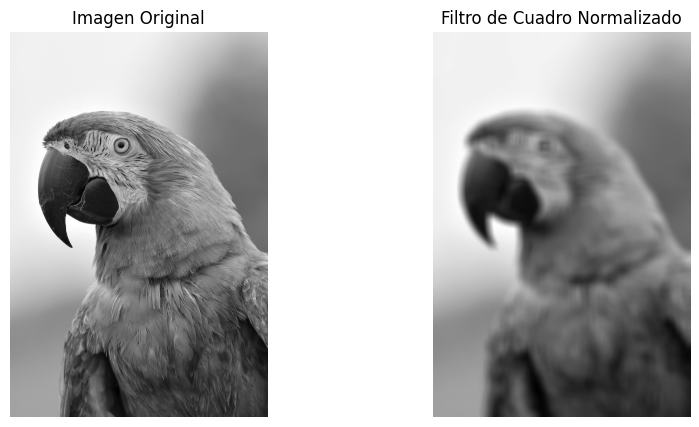

In [ ]:
img_cuadro = cv2.boxFilter(img, ddepth=-1, ksize=(151, 151), normalize=True)

# Visualización comparativa
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_cuadro, cmap='gray')
plt.title('Filtro de Cuadro Normalizado')
plt.axis('off')

plt.show()

##**Filtro Gaussiano**

###**Definición**

Es una implementación específica y estandarizada del filtro de media bidimensional. Se caracteriza por utilizar un kernel (núcleo de convolución) de coeficientes constantes y homogéneos, donde cada elemento tiene un valor de 1. Para asegurar que la ganancia de corriente continua (DC) sea unitaria y así evitar que la imagen resultante aumente artificialmente su brillo global, el resultado matricial se multiplica por un factor de normalización equivalente al recíproco del área total del kernel.

Matemáticamente:

$$G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$


###**Ventajas**
* Reduce ruido de manera suave y natural
* Preserva mejor la estructura general que un promedio simple
* Muy útil antes de detectar bordes (ej: antes de aplicar Laplaciano o Canny)
###**Desventajas**
* Difumina los bordes (pierde detalles finos)
* No elimina bien ruido impulsivo (tipo sal y pimienta)
* Puede hacer la imagen “borrosa” si σ es alto

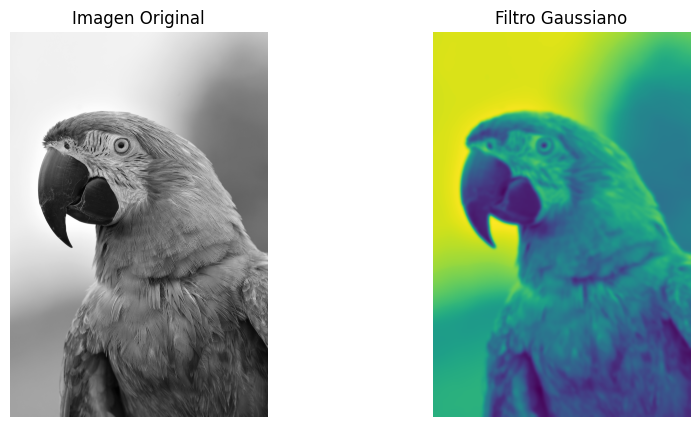

In [ ]:
# Aplicación del filtro Gaussiano con un kernel de 151x151 y desviación estándar sigmaX=0
# El sigmaY se calcula automáticamente si se pone en 0
img_gauss = cv2.GaussianBlur(img, (151, 151), 0)

# Visualización comparativa
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gauss)
plt.title('Filtro Gaussiano')
plt.axis('off')

plt.show()

##**Filtro Laplace**

###**Definición**

El filtro Laplaciano es un operador de segunda derivada que se usa para detectar bordes. Resalta cambios bruscos de intensidad (es decir, bordes).

Se basa en:

$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$



###**Ventajas**
* Detecta bordes en todas las direcciones (no solo horizontal/vertical)
* Resalta detalles finos
* Fácil de implementar
###**Desventajas**
* Muy sensible al ruido (por eso casi siempre se usa después de un gaussiano)
* Puede generar bordes dobles
* No indica dirección del borde (a diferencia de Sobel)

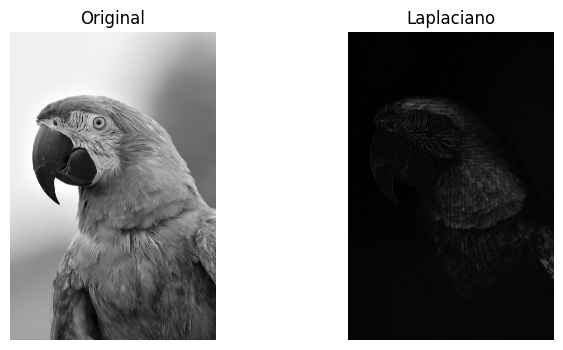

In [ ]:
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplaciano')
plt.axis('off')

plt.show()

##**Filtro Sobel**

###**Definición**

El filtro Sobel calcula la derivada de la imagen en dirección horizontal y vertical para detectar cambios de intensidad (bordes).

Genera dos imágenes:

$G_x$ : cambios en horizontal

$G_y$ : cambios en vertical

Y el borde se obtiene combinando ambos:
$$ G = \sqrt{G_x^2 + G_y^2}$$


###**Ventajas**
* Detecta bordes y además su dirección
* Más robusto al ruido que Laplaciano
* Simple y rápido
###**Desventajas**
* Aún sensible al ruido (aunque menos)
* Bordes no tan definidos
* Necesitas combinar $G_x$ y $G_y$

	​


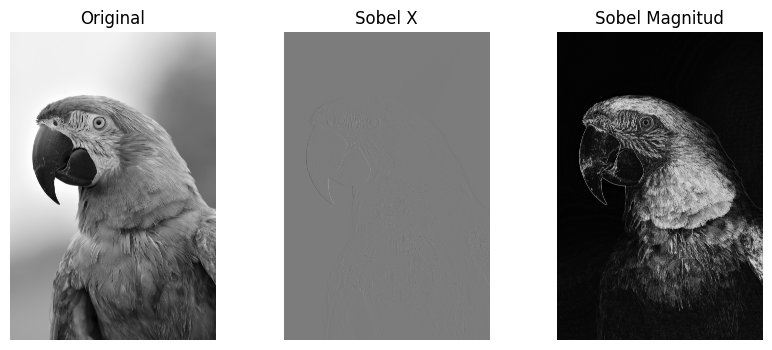

In [ ]:
# Gradiente en X
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel = cv2.magnitude(sobelx, sobely)
sobel = cv2.convertScaleAbs(sobel)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobelx, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel Magnitud')
plt.axis('off')

plt.show()

##**Filtro Canny**

###**Definición**

El detector de Canny es un algoritmo completo de detección de bordes que sigue estos pasos:

1. Suavizado (Gaussiano): Se aplica para atenuar el ruido y evitar detecciones falsas.
2. Cálculo de gradiente (Sobel): Se utilizan operadores de derivadas parciales para calcular la magnitud del gradiente $G$ y su dirección $\theta$ en cada píxel.

$$G = \sqrt{G_x^2 + G_y^2} \quad \text{y} \quad \theta = \arctan\left(\frac{G_y}{G_x}\right)$$


3. Supresión de no-máximos: Se "adelgazan" los bordes recorriendo la matriz de gradientes y conservando solo los píxeles que son máximos locales en la dirección del gradiente, dejando los bordes con un grosor de exactamente 1 píxel.
4. Umbral con histéresis (doble umbral):  Utiliza dos umbrales, uno alto ($T_{alto}$) y uno bajo ($T_{bajo}$). Los píxeles con un gradiente superior a $T_{alto}$ se marcan como "bordes fuertes". Los píxeles entre ambos umbrales se marcan como "bordes débiles" y solo se conservan si están conectados físicamente a un borde fuerte.

Resultado: bordes más limpios y delgados.



###**Ventajas**
* Bordes muy precisos
* Reduce falsos positivos
* Produce líneas finas y continuas
* Es estándar en visión por computador
###**Desventajas**
* Más costoso computacionalmente
* Debes ajustar bien los umbrales
* Puede perder bordes si los thresholds son malos


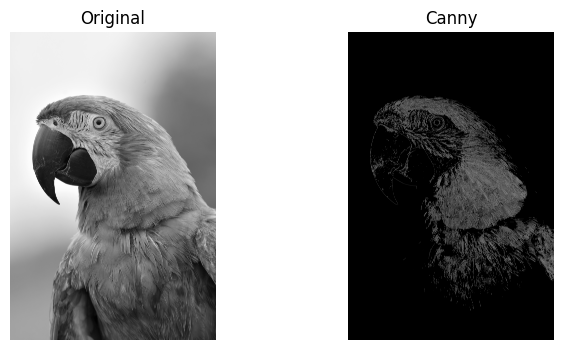

In [ ]:
# Los umbrales bajos y altos se ajustan experimentalmente
canny = cv2.Canny(img, 100, 200)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.show()

# **Parte 2: Descriptores**

1. Investigar métricas (por ejemplo: Accuracy, precisión, matriz de confusión, falsos positivos, falsos negativos, medidas F-Score)

##**Matriz de confusión, Falsos positivos y Falsos negativos**

La matriz de confusión es una herramienta de evaluación (generalmente una tabla $2 \times 2$ para problemas binarios) que permite visualizar el desempeño de un algoritmo de clasificación supervisada. Contrasta las predicciones hechas por el modelo contra los valores reales.

Esta matriz divide los resultados en cuatro cuadrantes fundamentales:

* **Verdaderos Positivos (VP / TP):** El modelo predijo que el evento ocurriría (clase positiva) y el evento realmente ocurrió. (Ej: El modelo predice que un correo es Spam, y efectivamente lo es).

* **Verdaderos Negativos (VN / TN):** El modelo predijo que el evento NO ocurriría (clase negativa) y el evento no ocurrió. (Ej: Predice que no es Spam, y es un correo normal).

Y estos son los dos tipos de errores que el modelo puede cometer:

* **Falsos Positivos (FP) - Error Tipo I:** El modelo predice incorrectamente la clase positiva. Es decir, genera una "falsa alarma".

* **Falsos Negativos (FN) - Error Tipo II:** El modelo predice incorrectamente la clase negativa. Es decir, "se le escapa" un evento que sí ocurrió.


## **Accuracy**

La exactitud es la métrica más intuitiva. Mide la proporción total de predicciones correctas (tanto positivas como negativas) sobre la cantidad total de casos evaluados. Básicamente responde a la pregunta: De todas las predicciones que hizo el modelo, ¿qué porcentaje acertó?Matemáticamente:

$$Accuracy = \frac{VP + VN}{VP + VN + FP + FN}$$

**Ventajas**
* Es muy fácil de entender e interpretar.


**Desventajas**
* Es engañosa en conjuntos de datos desbalanceados. Si se tiene un dataset con 99 transacciones legítimas y 1 fraude, un modelo "tonto" que siempre prediga "legítimo" tendrá un Accuracy del 99%, pero será completamente inútil para detectar fraudes (que es el objetivo real).

##**Precisión**

La precisión se enfoca exclusivamente en la calidad de las predicciones positivas. Responde a la pregunta: De todas las veces que el modelo predijo un resultado positivo, ¿cuántas veces tuvo razón? Esta métrica penaliza fuertemente a los Falsos Positivos

Matemáticamente:
$$Precision = \frac{VP}{VP + FP}$$

**Cuándo es importante:**
La precisión es crucial cuando el costo de un Falso Positivo es muy alto. Por ejemplo, en un sistema de recomendación de videos o en un filtro de correos. Si el filtro de Spam tiene baja precisión, enviará correos importantes (de trabajo o universidad) a la bandeja de correo no deseado, causando un problema grave al usuario.

##**Recall**

La sensibilidad mide la capacidad del modelo para encontrar todos los casos positivos reales. Penaliza los Falsos Negativos. Su fórmula es:

$Recall = \frac{VP}{VP + FN}$.

Es vital cuando un Falso Negativo es peligroso (ej: no detectar un tumor en un examen médico).

##**Medida F-Score (F1-Score)**

El F1-Score es una métrica única que combina la Precisión y el Recall en un solo número utilizando la media armónica. Esta métrica busca encontrar un equilibrio, ya que en los modelos de clasificación predictiva suele haber una relación inversa entre precisión y recall (si se ajusta el modelo para subir la precisión, suele bajar el recall, y viceversa).

Matemáticamente:

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**Ventajas**
* Es la métrica definitiva cuando se trabaja con conjuntos de datos desbalanceados, ya que no se deja engañar por la cantidad masiva de Verdaderos Negativos (los cuales ni siquiera aparecen en su fórmula).
* Un F1-Score alto garantiza que el modelo es robusto, teniendo pocos falsos positivos y pocos falsos negativos al mismo tiempo.

**Desventaja**
* Asume que tanto los Falsos Positivos como los Falsos Negativos tienen exactamente el mismo costo o gravedad, lo cual no siempre es cierto en problemas del mundo real.